## Interactions, Delta-Deltas, and How We Measure Uncertainty

*"Isn't a delta-delta just an interaction term in disguise?"*

People ask this a lot, and the answer is: mostly, yes — but the uncertainty tells a different story, and that difference is the whole point.

You calculate a mean. Then you wonder: how precise is this estimate?

For a simple mean difference, this question is already important. For a delta-delta, it becomes even more important. A delta-delta asks whether one change is larger than another change: for example, whether a treatment effect is larger in an experimental genotype than in a control genotype.

The estimate itself is just arithmetic. In a simple 2×2 design with dummy (treatment) coding, the delta-delta mean is exactly the `group × treatment` interaction coefficient in a saturated linear model. This equivalence depends on the coding scheme: with effect (sum-to-zero) coding, the interaction coefficient is scaled differently — in a 2×2 design it is one quarter of the delta-delta. The same basic interaction question is also asked by a two-way ANOVA: does the effect of one factor depend on the other? Regression and ANOVA can express the same general linear model structure, but the meaning of coefficients depends on the coding scheme used for categorical variables and interactions.[^ucla-interactions]

The uncertainty is where the methods part ways.

A classical confidence interval usually starts with a mathematical story about the estimate. For a simple mean, that story often relies on the sampling distribution of the mean being approximately normal. For regression coefficients, the usual interval relies on the fitted model: independent observations, a correctly specified linear structure, residual variance, degrees of freedom, and a theoretical reference distribution. These assumptions may be reasonable, but they are still assumptions.

A bootstrap confidence interval takes a different route. DABEST resamples the observed data with replacement, recomputes the effect size on each resample, and uses the resulting resampled effect-size distribution to form the confidence interval — with BCa correction applied.[^dabest-bootstrap] The bootstrap was introduced by Efron as a computational approach to estimating uncertainty from resampling.[^efron-bootstrap]

That is why the bootstrap CI feels empirical. It asks: if I repeatedly resample data like the data I actually observed, how much does my estimate wobble? That said, the bootstrap is not assumption-free. BCa correction can be unreliable when samples are very small (n < 10 per group) or when outcomes are highly discrete, because the resampling distribution itself becomes unstable.

This matters in practice because real biological data often make the usual textbook picture uncomfortable: small sample sizes, skewed distributions, unequal variances, batches, and the occasional outlier that pulls the mean around. The bootstrap does not make these problems disappear, but it changes the question. Instead of deriving uncertainty only from a theoretical standard-error formula, it directly recomputes the statistic on resampled versions of the observed dataset. For well-behaved data with reasonable group sizes (say, n ≥ 20 per cell), bootstrap and model-based CIs are often numerically similar — width ratios near 1.0. The gap opens up meaningfully when data are skewed, variances are unequal across groups, or outliers are present. Those are precisely the conditions where the bootstrap's empirical approach is most valuable.

This fits the broader estimation-statistics argument: report effect sizes and confidence intervals, not only whether a P value crossed a threshold. Gardner and Altman made this argument in "Confidence intervals rather than P values," and Cumming's "new statistics" similarly emphasises estimation based on effect sizes, confidence intervals, and meta-analysis.[^gardner-altman][^cumming-new-statistics]

### Same arithmetic in a simple 2×2 design

| Method | What you calculate | With dummy (treatment) coding |
|---|---|---|
| Delta-delta mean | Difference between two mean differences | The raw interaction estimate |
| Regression interaction beta | `group × treatment` coefficient | **Exactly equal** to the delta-delta |
| Regression interaction beta | `group × treatment` coefficient (effect/sum coding) | Delta-delta ÷ 4 — scaled, not equal |
| ANOVA interaction | Non-additive effect of two factors | Same interaction question, no estimate of size |

### Different uncertainty machinery

| Method | Uncertainty output | How uncertainty is built |
|---|---|---|
| Bootstrap delta-delta CI | Empirical/resampling CI | Resample observed data and recompute the full delta-delta |
| Regression beta CI | Model-based CI | Use model assumptions, a standard error formula, and usually a t distribution |
| ANOVA interaction P value | Model-based test | Use an F statistic under a no-interaction null |

### A numerical illustration

The cells below generate a synthetic 2×2 dataset with the following target means:

| Group | Vehicle | Drug | Difference |
|---|---:|---:|---:|
| WT | 10 | 12 | +2 |
| KO | 9 | 18 | +9 |

The delta-delta is (18 − 9) − (12 − 10) = **+7**.

The DABEST estimation plot, the regression interaction coefficient, and the two-way ANOVA all recover the same point estimate. The confidence intervals and the P value come from different machinery.

A companion Colab notebook extends this with a larger dataset, a messier unbalanced variant, and a side-by-side plot of the bootstrap distribution against the model-based CI: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sangyu/portfolio/blob/main/nbs/blog/same_estimate_different_uncertainty_colab.ipynb)

In [1]:
#| output: false
#| warning: false
import numpy as np
import pandas as pd
import dabest
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.stats.anova as sm_anova

rng = np.random.default_rng(7)
n = 25

df = pd.DataFrame({
    'measurement': np.concatenate([
        rng.normal(10, 2, n),   # WT Vehicle
        rng.normal(12, 2, n),   # WT Drug
        rng.normal(9,  2, n),   # KO Vehicle
        rng.normal(18, 2, n),   # KO Drug
    ]),
    'genotype':  ['WT']*(n*2) + ['KO']*(n*2),
    'treatment': (['Vehicle']*n + ['Drug']*n) * 2,
})

Pre-compiling numba functions for DABEST...


Compiling numba functions:   0%|          | 0/11 [00:00<?, ?it/s]

Compiling numba functions:   9%|▉         | 1/11 [00:00<00:01,  7.19it/s]

Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 64.22it/s]

Numba compilation complete!


#### DABEST delta-delta estimation plot

The upper panel shows the raw data and group means. The lower panel shows the two mean differences (WT Drug − WT Vehicle; KO Drug − KO Vehicle) and their delta — the delta-delta — with a 95% bootstrap BCa confidence interval.

/Applications/anaconda3/envs/DabestNMethRevision/lib/python3.10/site-packages/dabest/plot_tools.py:2592: UserWarning: 8.0% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
/Applications/anaconda3/envs/DabestNMethRevision/lib/python3.10/site-packages/dabest/plot_tools.py:2592: UserWarning: 8.0% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)


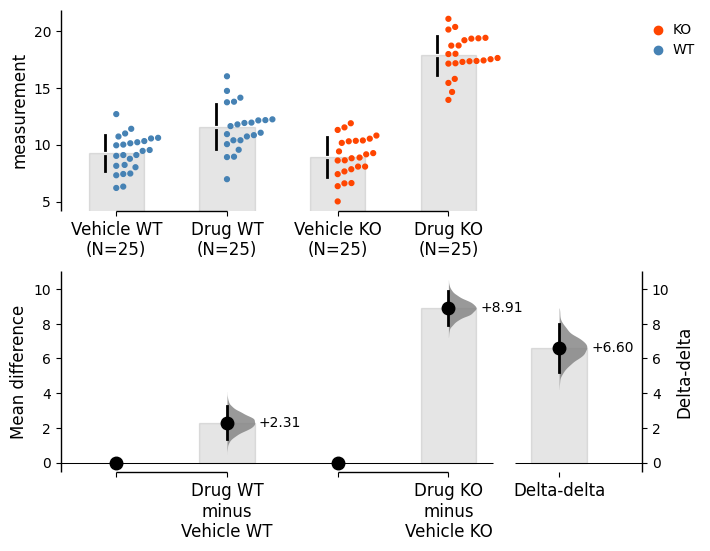

In [2]:
#| warning: false
analysis = dabest.load(
    df,
    x=['treatment', 'genotype'],
    y='measurement',
    delta2=True,
    experiment='genotype',
    experiment_label=['WT', 'KO'],
    x1_level=['Vehicle', 'Drug'],
)
fig = analysis.mean_diff.plot(
    raw_marker_size=3,
    bar_width=0.25,
    raw_desat=1,
    contrast_desat=1,
    custom_palette={'WT': 'steelblue', 'KO': 'orangered'},
    raw_bars_kwargs={'alpha': 0.1},
    contrast_bars_kwargs={'alpha': 0.1},
    contrast_errorbar_kwargs={'color': 'black', 'lw': 2, 'linestyle': '-', 'zorder': 1},
)
plt.tight_layout()

#### Regression: interaction coefficient and model-based CI

With dummy (treatment) coding — the default in statsmodels — the interaction coefficient is directly the delta-delta: it estimates how much the Drug effect changes from WT to KO. The CI comes from the model's standard error and a t distribution.

In [3]:
model = smf.ols('measurement ~ C(genotype) * C(treatment)', data=df).fit()

coef_table = model.summary2().tables[1][['Coef.', '[0.025', '0.975]', 'P>|t|']]
print(coef_table.to_string())

                                               Coef.     [0.025     0.975]         P>|t|
Intercept                                  17.846924  17.145814  18.548035  5.725496e-71
C(genotype)[T.WT]                          -6.277980  -7.269500  -5.286460  5.373939e-22
C(treatment)[T.Vehicle]                    -8.906672  -9.898192  -7.915152  3.175259e-32
C(genotype)[T.WT]:C(treatment)[T.Vehicle]   6.598166   5.195945   8.000387  3.889043e-15


#### Two-way ANOVA: interaction F test

In [4]:
anova_table = sm_anova.anova_lm(model, typ=2)
print(anova_table.to_string())

                              sum_sq    df           F        PR(>F)
C(genotype)               221.845711   1.0   71.129908  3.402525e-13
C(treatment)              786.126199   1.0  252.053934  1.342959e-28
C(genotype):C(treatment)  272.098739   1.0   87.242427  3.889043e-15
Residual                  299.412566  96.0         NaN           NaN


The interaction row of the ANOVA table and the interaction coefficient in the regression table both point at the same effect. The bootstrap CI in the DABEST plot is empirically derived from the data; the regression CI is derived from the model's residual variance and degrees of freedom. In clean, balanced, normally distributed data these will be similar. In practice they can differ — and knowing *why* they can differ is reason enough to look at both.

### When the three stop matching neatly

The equivalence is cleanest for a simple 2×2 ordinary least-squares model with matching contrasts. The answers can diverge when the design is unbalanced, when Type I/II/III sums of squares are chosen differently, when contrast coding changes the coefficient, when covariates are added, when observations are paired or clustered, when mixed effects are needed, when robust standard errors are used, when outcomes are modeled with logistic or Poisson regression, or when effects are estimated on a transformed scale. Statsmodels explicitly exposes Type I/II/III ANOVA choices and robust covariance options, which is a reminder that "the interaction P value" is not a single assumption-free object.[^statsmodels-anova]

The takeaway is simple: **the mean is the estimate; the interval is the story of how much we trust it.**

[^ucla-interactions]: UCLA Statistical Methods and Data Analytics. "Regression with SPSS Chapter 6: More on Interactions of Categorical Variables." <https://stats.oarc.ucla.edu/spss/webbooks/reg/chapter6/regressionwith-spsschapter-6-more-on-interactions-of-categorical-variablesdraft-version/>

[^dabest-bootstrap]: DABEST. "Bootstrap Confidence Intervals." <https://acclab.github.io/DABEST-python/blog/posts/bootstraps/bootstraps.html>

[^efron-bootstrap]: Efron, B. (1979). "Bootstrap Methods: Another Look at the Jackknife." *The Annals of Statistics*, 7(1), 1–26. <https://projecteuclid.org/journals/annals-of-statistics/volume-7/issue-1/Bootstrap-Methods-Another-Look-at-the-Jackknife/10.1214/aos/1176344552.short>

[^gardner-altman]: Gardner, M. J., & Altman, D. G. (1986). "Confidence intervals rather than P values: estimation rather than hypothesis testing." *British Medical Journal*, 292, 746–750. <https://pmc.ncbi.nlm.nih.gov/articles/PMC1339793/>

[^cumming-new-statistics]: Cumming, G. (2014). "The new statistics: why and how." *Psychological Science*, 25(1), 7–29. <https://pubmed.ncbi.nlm.nih.gov/24220629/>

[^statsmodels-anova]: Statsmodels. `statsmodels.stats.anova.anova_lm` documentation. <https://www.statsmodels.org/stable/generated/statsmodels.stats.anova.anova_lm.html>